## 1) Descripción del problema
En un centro de atención médica se requiere un sistema para gestionar pacientes usando **estructuras de datos lineales implementadas desde cero** (sin `collections`, sin `deque`, sin librerías externas).

- **Pacientes normales (N):** se atienden por orden de llegada (FIFO).
- **Pacientes críticos (C):** tienen prioridad sobre los normales, pero entre críticos también se respeta FIFO.
- **Atención:** solo puede atenderse un paciente a la vez y, al atenderlo, se elimina del sistema.

Además, se solicita implementar dos estructuras base:

1. **Pila (LIFO):** métodos `push(elemento)`, `pop()`, `top()`, `esta_vacia()`, `tamaño()`.
2. **Cola (FIFO):** métodos `encolar(elemento)`, `desencolar()`, `frente()`, `esta_vacia()`, `tamaño()`.

El objetivo del sistema es procesar `n` acciones de entrada y producir la salida exacta según el enunciado del laboratorio.

## 2) Requerimientos
### Requerimientos funcionales
- **RF1.** El sistema debe implementar un **Árbol Binario de Búsqueda (BST)** con operaciones `insertar(clave, valor)`, `buscar(clave)`, `eliminar(clave)`, `obtener_minimo()`, `extraer_minimo()`, `inorden()`, `esta_vacio()`, `tamaño()`.
- **RF2.** El sistema debe implementar un **Árbol AVL** con operaciones `insertar(clave, valor)`, `buscar(clave)`, `obtener_minimo()`, `extraer_minimo()`, `esta_vacio()`, `tamaño()`, aplicando rotaciones para mantener balance.
- **RF3.** El sistema debe gestionar pacientes en espera con dos árboles AVL: uno para críticos y otro para normales.
- **RF4.** El sistema debe registrar pacientes normales con la acción `N nombre` y mostrar `Paciente N nuevo : nombre`.
- **RF5.** El sistema debe registrar pacientes críticos con la acción `C nombre` y mostrar `Paciente C nuevo : nombre`.
- **RF6.** El sistema debe atender pacientes con la acción `A`, priorizando críticos sobre normales y respetando FIFO dentro de cada categoría mediante una clave de turno creciente.
- **RF7.** El sistema debe guardar pacientes atendidos en un BST de historial.
- **RF8.** El sistema debe mostrar `no hay pacientes` cuando se intenta atender sin pacientes en espera.
- **RF9.** El sistema debe leer una cantidad `n` de acciones y procesarlas una por una.
- **RF10.** El sistema debe reportar `accion invalida` ante entradas incorrectas y continuar sin detenerse.

### Requerimientos no funcionales
- **RNF1.** No se permite el uso de `collections`, `deque` ni librerías externas; BST y AVL deben implementarse desde cero.
- **RNF2.** Las operaciones de inserción/búsqueda/extracción en AVL deben ejecutarse en tiempo $O(\log n)$ en el peor caso.
- **RNF3.** El código debe estar organizado en clases (`NodoBST`, `BST`, `NodoAVL`, `AVL`, `SistemaAtencionMedica`) y una función principal `main()`.
- **RNF4.** El programa debe ser robusto frente a entradas inesperadas: no debe detenerse ante comandos desconocidos, líneas vacías o formatos incorrectos.
- **RNF5.** El programa debe ejecutarse por consola, leyendo `stdin` y escribiendo en `stdout`, sin archivos externos.

## 3) Historias de usuario
A continuación se define **una historia por cada requerimiento funcional**.

1. **HU1 (RF1):** Como desarrollador, quiero un BST para almacenar y recuperar pares clave-valor de forma ordenada.
2. **HU2 (RF2):** Como desarrollador, quiero un AVL auto-balanceado para garantizar operaciones eficientes aun con muchas inserciones.
3. **HU3 (RF3):** Como administrador, quiero dos AVL (críticos y normales) para organizar turnos por prioridad.
4. **HU4 (RF4):** Como recepcionista, quiero registrar pacientes normales con `N nombre` y ver confirmación inmediata.
5. **HU5 (RF5):** Como recepcionista, quiero registrar pacientes críticos con `C nombre` y ver confirmación inmediata.
6. **HU6 (RF6):** Como médico, quiero atender con `A`, priorizando críticos y respetando FIFO por turno dentro de cada grupo.
7. **HU7 (RF7):** Como operador, quiero registrar cada paciente atendido en un BST de historial.
8. **HU8 (RF8):** Como usuario, quiero ver `no hay pacientes` cuando no haya personas en espera.
9. **HU9 (RF9):** Como evaluador, quiero que el sistema procese exactamente `n` acciones.
10. **HU10 (RF10):** Como usuario, quiero que entradas inválidas muestren `accion invalida` sin detener el programa.

## 4) Diagramas de flujo
Diagrama pendiente por completar.

*(Espacio reservado para agregar el diagrama de flujo posteriormente).*

## 5) Diagramas de secuencia
Diagrama pendiente por completar.

*(Espacio reservado para agregar el diagrama de secuencia posteriormente).*

## 6) Diagramas de casos de uso
Diagrama pendiente por completar.

*(Espacio reservado para agregar el diagrama de casos de uso posteriormente).*

## 7) Análisis de complejidad

### 7.1) Resumen del problema
El sistema procesa `n` acciones (`N nombre`, `C nombre`, `A`) usando dos árboles AVL para turnos en espera (críticos y normales) y un BST para historial de pacientes atendidos. Cada paciente recibe un turno creciente para preservar FIFO dentro de su categoría. Con AVL, inserción y extracción del mínimo se mantienen en $O(\log n)$, evitando el costo lineal de desplazar elementos de una lista.

### 7.2) Tabla compacta de complejidad

| Componente | Operación principal | Tiempo | Espacio adicional |
|---|---|---|---|
| `BST` | `insertar`, `buscar`, `eliminar` | $O(h)$ | $O(h)$ recursión |
| `BST` | `obtener_minimo`, `inorden` | $O(h)$ / $O(n)$ | $O(h)$ / $O(n)$ |
| `AVL` | `insertar`, `buscar`, `extraer_minimo` | $O(\log n)$ | $O(\log n)$ recursión |
| `AVL` | rotaciones (`izq`, `der`) | $O(1)$ | $O(1)$ |
| `SistemaAtencionMedica` | `agregar_paciente` | $O(\log n)$ | $O(1)$ |
| `SistemaAtencionMedica` | `atender_paciente` | $O(\log n)$ | $O(1)$ |
| `main` | Procesar `n` acciones | $O(n\log n)$ | $O(n)$ |

Donde `h` es la altura del árbol; en AVL, `h = O(\log n)`.

### 7.3) Complejidad total

Sea `n` el número total de acciones. Cada alta o atención realiza a lo sumo una inserción o extracción en AVL.

$$
T(n)=\sum_{i=1}^{n} O(\log i)=O(n\log n)
$$

| Escenario | Complejidad temporal | Complejidad espacial |
|---|---|---|
| Mejor caso (muchas acciones `A` con colas vacías) | $\Theta(n)$ | $\Theta(1)$ |
| Peor caso (muchas altas y atenciones) | $\Theta(n\log n)$ | $\Theta(n)$ |
| Caso promedio | $O(n\log n)$ | $O(n)$ |

### 7.4) Gráficas mejor/peor caso
*(Espacio reservado para agregar las gráficas posteriormente).*

### 7.5) Conclusión
La migración de colas lineales a AVL permite pasar de un peor caso cuadrático $O(n^2)$ a $O(n\log n)$ para el procesamiento completo. Se mantiene la prioridad de críticos sobre normales y se preserva FIFO dentro de cada categoría mediante turnos crecientes. El uso de BST para historial facilita consultas ordenadas y auditoría de pacientes atendidos.
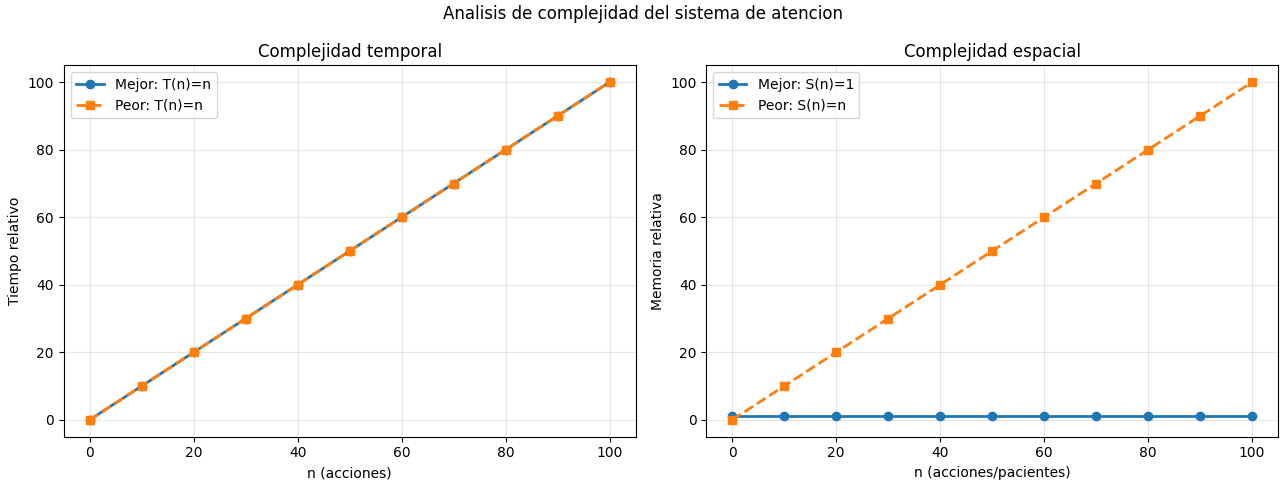

## 8) Tests
Conjunto de pruebas propuesto para validar el sistema con BST/AVL:

### **Escenario 1: Prioridad de Triage (C sobre N)**
Descripción: valida que pacientes críticos salgan primero, manteniendo FIFO dentro de cada categoría.

**Entrada:**
4
N Carlos
C Amanda
A
A

**Resultado Esperado:**
Paciente N nuevo : Carlos
Paciente C nuevo : Amanda
Se atiende a Amanda
Se atiende a Carlos

### **Escenario 2: FIFO en misma prioridad**
Descripción: asegura orden de llegada entre pacientes normales almacenados en AVL por turno.

**Entrada:**
5
N Juan
N Pedro
N Maria
A
A

**Resultado Esperado:**
Paciente N nuevo : Juan
Paciente N nuevo : Pedro
Paciente N nuevo : Maria
Se atiende a Juan
Se atiende a Pedro

### **Escenario 3: Sin pacientes en espera**
Descripción: verifica respuesta correcta cuando no hay pacientes para atender.

**Entrada:**
3
C Urgente
A
A

**Resultado Esperado:**
Paciente C nuevo : Urgente
Se atiende a Urgente
no hay pacientes

### **Escenario 4: Entradas inválidas**
Descripción: valida robustez ante comandos mal formados o desconocidos.

**Entrada:**
6
N
X Pepe

C
A

**Resultado Esperado:**
accion invalida
accion invalida
accion invalida
accion invalida
no hay pacientes

## 9) Código funcional
Implementación completa del laboratorio con:

- Estructura `BST` para historial y consultas ordenadas.
- Estructura `AVL` para colas de espera optimizadas por turno.
- Sistema de atención médica con prioridad de críticos.
- Lectura de `n` acciones por entrada estándar.
- Salida exacta según el formato solicitado.
- Manejo robusto de entradas inválidas sin detener el programa.

In [3]:
# Parte 1: Implementacion de arboles BST y AVL
class NodoBST:
    def __init__(self, clave, valor):
        self.clave = clave
        self.valor = valor
        self.izq = None
        self.der = None


class BST:
    def __init__(self):
        self.raiz = None
        self._tam = 0

    def esta_vacio(self):
        return self.raiz is None

    def tamaño(self):
        return self._tam

    def insertar(self, clave, valor):
        self.raiz, insertado_nuevo = self._insertar_rec(self.raiz, clave, valor)
        if insertado_nuevo:
            self._tam += 1

    def _insertar_rec(self, nodo, clave, valor):
        if nodo is None:
            return NodoBST(clave, valor), True
        if clave < nodo.clave:
            nodo.izq, nuevo = self._insertar_rec(nodo.izq, clave, valor)
            return nodo, nuevo
        if clave > nodo.clave:
            nodo.der, nuevo = self._insertar_rec(nodo.der, clave, valor)
            return nodo, nuevo
        nodo.valor = valor
        return nodo, False

    def buscar(self, clave):
        actual = self.raiz
        while actual is not None:
            if clave < actual.clave:
                actual = actual.izq
            elif clave > actual.clave:
                actual = actual.der
            else:
                return actual.valor
        return None

    def obtener_minimo(self):
        if self.raiz is None:
            return None
        nodo = self.raiz
        while nodo.izq is not None:
            nodo = nodo.izq
        return nodo.clave, nodo.valor

    def eliminar(self, clave):
        self.raiz, eliminado = self._eliminar_rec(self.raiz, clave)
        if eliminado:
            self._tam -= 1
        return eliminado

    def _eliminar_rec(self, nodo, clave):
        if nodo is None:
            return None, False

        if clave < nodo.clave:
            nodo.izq, eliminado = self._eliminar_rec(nodo.izq, clave)
            return nodo, eliminado

        if clave > nodo.clave:
            nodo.der, eliminado = self._eliminar_rec(nodo.der, clave)
            return nodo, eliminado

        if nodo.izq is None:
            return nodo.der, True
        if nodo.der is None:
            return nodo.izq, True

        sucesor = nodo.der
        while sucesor.izq is not None:
            sucesor = sucesor.izq
        nodo.clave, nodo.valor = sucesor.clave, sucesor.valor
        nodo.der, _ = self._eliminar_rec(nodo.der, sucesor.clave)
        return nodo, True

    def extraer_minimo(self):
        minimo = self.obtener_minimo()
        if minimo is None:
            return None
        self.eliminar(minimo[0])
        return minimo

    def inorden(self):
        resultado = []
        self._inorden_rec(self.raiz, resultado)
        return resultado

    def _inorden_rec(self, nodo, resultado):
        if nodo is None:
            return
        self._inorden_rec(nodo.izq, resultado)
        resultado.append((nodo.clave, nodo.valor))
        self._inorden_rec(nodo.der, resultado)


class NodoAVL:
    def __init__(self, clave, valor):
        self.clave = clave
        self.valor = valor
        self.izq = None
        self.der = None
        self.altura = 1


class AVL:
    def __init__(self):
        self.raiz = None
        self._tam = 0

    def esta_vacio(self):
        return self.raiz is None

    def tamaño(self):
        return self._tam

    def _altura(self, nodo):
        return 0 if nodo is None else nodo.altura

    def _actualizar_altura(self, nodo):
        nodo.altura = 1 + max(self._altura(nodo.izq), self._altura(nodo.der))

    def _factor_balance(self, nodo):
        return self._altura(nodo.izq) - self._altura(nodo.der)

    def _rotar_derecha(self, y):
        x = y.izq
        t2 = x.der
        x.der = y
        y.izq = t2
        self._actualizar_altura(y)
        self._actualizar_altura(x)
        return x

    def _rotar_izquierda(self, x):
        y = x.der
        t2 = y.izq
        y.izq = x
        x.der = t2
        self._actualizar_altura(x)
        self._actualizar_altura(y)
        return y

    def _rebalancear(self, nodo):
        self._actualizar_altura(nodo)
        fb = self._factor_balance(nodo)

        if fb > 1:
            if self._factor_balance(nodo.izq) < 0:
                nodo.izq = self._rotar_izquierda(nodo.izq)
            return self._rotar_derecha(nodo)

        if fb < -1:
            if self._factor_balance(nodo.der) > 0:
                nodo.der = self._rotar_derecha(nodo.der)
            return self._rotar_izquierda(nodo)

        return nodo

    def insertar(self, clave, valor):
        self.raiz, insertado_nuevo = self._insertar_rec(self.raiz, clave, valor)
        if insertado_nuevo:
            self._tam += 1

    def _insertar_rec(self, nodo, clave, valor):
        if nodo is None:
            return NodoAVL(clave, valor), True

        if clave < nodo.clave:
            nodo.izq, nuevo = self._insertar_rec(nodo.izq, clave, valor)
        elif clave > nodo.clave:
            nodo.der, nuevo = self._insertar_rec(nodo.der, clave, valor)
        else:
            nodo.valor = valor
            return nodo, False

        nodo = self._rebalancear(nodo)
        return nodo, nuevo

    def buscar(self, clave):
        actual = self.raiz
        while actual is not None:
            if clave < actual.clave:
                actual = actual.izq
            elif clave > actual.clave:
                actual = actual.der
            else:
                return actual.valor
        return None

    def obtener_minimo(self):
        if self.raiz is None:
            return None
        nodo = self.raiz
        while nodo.izq is not None:
            nodo = nodo.izq
        return nodo.clave, nodo.valor

    def extraer_minimo(self):
        if self.raiz is None:
            return None
        self.raiz, minimo = self._extraer_minimo_rec(self.raiz)
        self._tam -= 1
        return minimo

    def _extraer_minimo_rec(self, nodo):
        if nodo.izq is None:
            return nodo.der, (nodo.clave, nodo.valor)

        nodo.izq, minimo = self._extraer_minimo_rec(nodo.izq)
        nodo = self._rebalancear(nodo)
        return nodo, minimo


class SistemaAtencionMedica:
    def __init__(self):
        self.arbol_criticos = AVL()
        self.arbol_normales = AVL()
        self.historial = BST()
        self.turno_llegada = 0
        self.turno_atendido = 0

    def agregar_paciente(self, tipo, nombre):
        nombre = nombre.strip()
        if not nombre:
            return "accion invalida"

        self.turno_llegada += 1
        if tipo == "C":
            self.arbol_criticos.insertar(self.turno_llegada, nombre)
            return f"Paciente C nuevo : {nombre}"
        if tipo == "N":
            self.arbol_normales.insertar(self.turno_llegada, nombre)
            return f"Paciente N nuevo : {nombre}"
        return "accion invalida"

    def atender_paciente(self):
        if not self.arbol_criticos.esta_vacio():
            _, paciente = self.arbol_criticos.extraer_minimo()
        elif not self.arbol_normales.esta_vacio():
            _, paciente = self.arbol_normales.extraer_minimo()
        else:
            return "no hay pacientes"

        self.turno_atendido += 1
        self.historial.insertar(self.turno_atendido, paciente)
        return f"Se atiende a {paciente}"

    def historial_en_orden(self):
        return [valor for _, valor in self.historial.inorden()]


def main():
    sistema = SistemaAtencionMedica()

    try:
        linea_n = input().strip()
    except EOFError:
        return

    if not linea_n.isdigit():
        return

    n = int(linea_n)
    for _ in range(n):
        try:
            linea = input().strip()
        except EOFError:
            break

        if not linea:
            print("accion invalida")
            continue

        partes = linea.split(maxsplit=1)
        comando = partes[0]

        if comando == "A" and len(partes) == 1:
            print(sistema.atender_paciente())
        elif comando in ("N", "C") and len(partes) == 2 and partes[1].strip():
            print(sistema.agregar_paciente(comando, partes[1]))
        else:
            print("accion invalida")


main()

## 10) Tests aplicados (extras)
Pruebas adicionales ejecutadas sobre la lógica del sistema:

1. **Prueba extra n=20 (secuencia mixta)**
- Se alternan inserciones N/C y atenciones A.
- Se valida que nunca se atienda normal si existe crítico pendiente.

2. **Prueba extra n=30 (estrés básico)**
- Se ejecutan múltiples encolados y atenciones.
- Se valida estabilidad FIFO dentro de cada prioridad.

3. **Prueba de validación (acción inválida / entrada incorrecta)**
- Se prueba comando no permitido y entrada vacía.
- Se espera `accion invalida` sin detener el programa.

A continuación se muestran pruebas unitarias directas (asserts).

In [4]:
# Pruebas extra de funcionalidad y estructura
def _altura_y_balance_ok(nodo):
    if nodo is None:
        return 0, True

    h_izq, ok_izq = _altura_y_balance_ok(nodo.izq)
    h_der, ok_der = _altura_y_balance_ok(nodo.der)
    ok_actual = abs(h_izq - h_der) <= 1 and nodo.altura == 1 + max(h_izq, h_der)
    return 1 + max(h_izq, h_der), ok_izq and ok_der and ok_actual


def prueba_prioridad_y_fifo():
    sistema = SistemaAtencionMedica()
    assert sistema.agregar_paciente("N", "Carlos") == "Paciente N nuevo : Carlos"
    assert sistema.agregar_paciente("C", "Amanda") == "Paciente C nuevo : Amanda"
    assert sistema.agregar_paciente("N", "Pedro") == "Paciente N nuevo : Pedro"
    assert sistema.agregar_paciente("C", "Marta") == "Paciente C nuevo : Marta"

    # Criticos primero, respetando FIFO interno
    assert sistema.atender_paciente() == "Se atiende a Amanda"
    assert sistema.atender_paciente() == "Se atiende a Marta"
    # Luego normales en FIFO
    assert sistema.atender_paciente() == "Se atiende a Carlos"
    assert sistema.atender_paciente() == "Se atiende a Pedro"
    assert sistema.atender_paciente() == "no hay pacientes"

    assert sistema.historial_en_orden() == ["Amanda", "Marta", "Carlos", "Pedro"]
    print("Prueba prioridad/FIFO: OK")


def prueba_balance_avl_intenso():
    avl = AVL()
    for i in range(1, 101):
        avl.insertar(i, f"P{i}")

    _, balance_ok = _altura_y_balance_ok(avl.raiz)
    assert balance_ok, "El AVL perdio balance despues de inserciones"
    assert avl.tamaño() == 100

    # Extracciones del minimo deben salir ordenadas
    for i in range(1, 101):
        clave, valor = avl.extraer_minimo()
        assert clave == i
        assert valor == f"P{i}"

    assert avl.esta_vacio()
    print("Prueba balance AVL intensivo: OK")


def prueba_bst_historial():
    bst = BST()
    datos = [(5, "Ana"), (2, "Luis"), (8, "Marta"), (1, "Pedro"), (3, "Laura")]
    for k, v in datos:
        bst.insertar(k, v)

    assert bst.buscar(3) == "Laura"
    assert bst.buscar(9) is None
    assert bst.obtener_minimo() == (1, "Pedro")

    assert bst.eliminar(2) is True
    assert bst.buscar(2) is None
    assert bst.tamaño() == 4
    assert [k for k, _ in bst.inorden()] == [1, 3, 5, 8]
    print("Prueba BST historial: OK")


def prueba_entradas_invalidas():
    sistema = SistemaAtencionMedica()
    assert sistema.agregar_paciente("X", "Test") == "accion invalida"
    assert sistema.agregar_paciente("N", "   ") == "accion invalida"
    assert sistema.atender_paciente() == "no hay pacientes"

    sistema.agregar_paciente("C", "Unico")
    assert sistema.atender_paciente() == "Se atiende a Unico"
    assert sistema.atender_paciente() == "no hay pacientes"
    print("Prueba entradas invalidas: OK")


prueba_prioridad_y_fifo()
prueba_balance_avl_intenso()
prueba_bst_historial()
prueba_entradas_invalidas()

Prueba prioridad/FIFO: OK
Prueba balance AVL intensivo: OK
Prueba BST historial: OK
Prueba entradas invalidas: OK
